# Reconhecimento de atividades no smartwatch — WISDM + LiteRT

Este notebook implementa o ciclo completo e reproduzível do trabalho: baixa o WISDM oficial, usa somente acelerômetro e giroscópio do **smartwatch**, filtra as atividades A/B/C/G/R, separa participantes antes de qualquer transformação, cria janelas temporais, treina uma CNN 1D compacta, converte para TFLite `int8` e exporta o pacote para o aplicativo Wear OS.

In [1]:
# Dependências do Google Colab
!pip -q install tensorflow pandas numpy scikit-learn matplotlib seaborn requests

In [2]:
from pathlib import Path
from collections import Counter
import hashlib
import json
import random
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

DATA_URL = ('https://archive.ics.uci.edu/static/public/507/'
            'wisdm%2Bsmartphone%2Band%2Bsmartwatch%2Bactivity%2Band%2Bbiometrics%2Bdataset.zip')
WORK_DIR = Path('/content/watch_har')
ZIP_PATH = WORK_DIR / 'wisdm.zip'
DATA_DIR = WORK_DIR / 'dataset'
EXPORT_DIR = WORK_DIR / 'export'

ACTIVITY_CODES = ['A', 'B', 'C', 'G', 'R']
ACTIVITY_NAMES = {
    'A': 'Walking',
    'B': 'Jogging',
    'C': 'Stairs',
    'G': 'Brushing Teeth',
    'R': 'Clapping',
}
LABEL_TO_INDEX = {code: i for i, code in enumerate(ACTIVITY_CODES)}
CHANNELS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
SAMPLE_RATE_HZ = 20
SAMPLE_PERIOD_S = 1.0 / SAMPLE_RATE_HZ
WINDOW_SECONDS = 5
WINDOW_SAMPLES = SAMPLE_RATE_HZ * WINDOW_SECONDS
HOP_SECONDS = 1
HOP_SAMPLES = SAMPLE_RATE_HZ * HOP_SECONDS
MAX_GAP_S = 0.250

print('TensorFlow:', tf.__version__)
print('Contrato:', (1, WINDOW_SAMPLES, len(CHANNELS)), ACTIVITY_CODES)

TensorFlow: 2.21.0
Contrato: (1, 100, 6) ['A', 'B', 'C', 'G', 'R']


## 1. Download e localização dos arquivos

O ZIP tem aproximadamente 295 MB. A busca pelos arquivos é feita pela estrutura e pelo nome, sem depender de uma pasta absoluta específica dentro do arquivo.

In [3]:
WORK_DIR.mkdir(parents=True, exist_ok=True)
if not ZIP_PATH.exists():
    with requests.get(DATA_URL, stream=True, timeout=180) as response:
        response.raise_for_status()
        with ZIP_PATH.open('wb') as output:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output.write(chunk)

DATA_DIR.mkdir(parents=True, exist_ok=True)
outer_marker = DATA_DIR / '.outer_zip_extracted'
if not outer_marker.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)
    outer_marker.touch()

# O pacote da UCI contém wisdm-dataset.zip dentro do ZIP externo.
# O laço também suporta novas camadas internas, caso a estrutura mude.
def extract_nested_zips(root):
    processed = set()
    while True:
        pending = [path for path in root.rglob('*.zip') if path not in processed]
        if not pending:
            break
        for nested_zip in pending:
            processed.add(nested_zip)
            destination = nested_zip.parent / f'{nested_zip.stem}_extracted'
            marker = destination / '.extraction_complete'
            if marker.exists():
                continue
            destination.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(nested_zip) as archive:
                archive.extractall(destination)
            marker.touch()
            print('ZIP interno extraído:', nested_zip.name, '->', destination)

extract_nested_zips(DATA_DIR)

def find_watch_files(sensor_name):
    matches = []
    for path in DATA_DIR.rglob('*'):
        if not path.is_file() or path.suffix.lower() != '.txt':
            continue
        name = path.name.lower()
        parts = {part.lower() for part in path.parts}
        is_watch = 'watch' in parts or '_watch' in path.stem.lower()
        is_sensor = sensor_name in parts or f'_{sensor_name}_' in name
        if name.startswith('data_') and is_watch and is_sensor:
            matches.append(path)
    return sorted(matches)

accel_files = find_watch_files('accel')
gyro_files = find_watch_files('gyro')
print('Arquivos watch/accel:', len(accel_files))
print('Arquivos watch/gyro :', len(gyro_files))
if not accel_files or not gyro_files:
    print('Arquivos encontrados após a extração (primeiros 30):')
    for candidate in list(DATA_DIR.rglob('*'))[:30]:
        print(' -', candidate.relative_to(DATA_DIR))
assert len(accel_files) == 51, 'Esperados 51 arquivos de acelerômetro do relógio'
assert len(gyro_files) == 51, 'Esperados 51 arquivos de giroscópio do relógio'

ZIP interno extraído: wisdm-dataset.zip -> /content/watch_har/dataset/wisdm-dataset_extracted
Arquivos watch/accel: 51
Arquivos watch/gyro : 51


## 2. Leitura e auditoria dos dados brutos

As unidades documentadas pelo WISDM são m/s² para acelerômetro e rad/s para giroscópio — as mesmas retornadas pelas APIs Android. O ponto e vírgula no fim de cada linha é removido explicitamente.

In [4]:
RAW_COLUMNS = ['subject', 'activity', 'timestamp', 'x', 'y', 'z']

def read_sensor_files(paths, sensor_name):
    frames = []
    for path in paths:
        frame = pd.read_csv(
            path, header=None, names=RAW_COLUMNS, dtype=str,
            on_bad_lines='skip', engine='python',
        )
        frame['z'] = frame['z'].str.replace(';', '', regex=False)
        frame = frame[frame['activity'].isin(ACTIVITY_CODES)].copy()
        for column in ['subject', 'timestamp', 'x', 'y', 'z']:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
        frame['sensor'] = sensor_name
        frames.append(frame)
    result = pd.concat(frames, ignore_index=True)
    result['subject'] = result['subject'].astype('Int64')
    return result

accel_raw = read_sensor_files(accel_files, 'accel')
gyro_raw = read_sensor_files(gyro_files, 'gyro')
raw = pd.concat([accel_raw, gyro_raw], ignore_index=True)

quality_before = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'null_count': raw.isna().sum(),
    'unique_values': raw.nunique(dropna=True),
})
display(quality_before)

invalid_rows = raw[['subject', 'timestamp', 'x', 'y', 'z']].isna().any(axis=1)
print('Linhas inválidas removidas:', int(invalid_rows.sum()))
raw = raw.loc[~invalid_rows].copy()
raw['subject'] = raw['subject'].astype(int)

duplicate_key = ['sensor', 'subject', 'activity', 'timestamp']
duplicate_count = int(raw.duplicated(duplicate_key).sum())
print('Duplicatas exatas por sensor/sujeito/atividade/tempo:', duplicate_count)
raw = raw.drop_duplicates(duplicate_key, keep='first')

assert set(raw['activity'].unique()) == set(ACTIVITY_CODES)
assert raw[['x', 'y', 'z']].apply(np.isfinite).all().all()
display(pd.crosstab([raw['sensor'], raw['activity']], columns='leituras'))

,dtype,null_count,unique_values
subject,Int64,0,51
activity,object,0,5
timestamp,int64,0,1078492
x,float64,0,1019051
y,float64,0,979349
z,float64,0,957246
sensor,object,0,2


Linhas inválidas removidas: 0
Duplicatas exatas por sensor/sujeito/atividade/tempo: 36039


col_0            leituras
sensor activity          
accel  A           206891
       B           202182
       C           203707
       G           205115
       R           205129
gyro   A           188928
       B           184230
       C           176813
       G           187156
       R           187173

In [5]:
# Detecta a unidade do timestamp a partir do intervalo mediano.
def infer_timestamp_divisor(frame):
    medians = []
    for _, group in frame.groupby(['sensor', 'subject', 'activity']):
        diffs = np.diff(np.sort(group['timestamp'].to_numpy(dtype=np.float64)))
        diffs = diffs[diffs > 0]
        if len(diffs):
            medians.append(np.median(diffs))
    median_step = float(np.median(medians))
    if median_step > 1_000_000:
        divisor = 1_000_000_000.0  # nanossegundos
    elif median_step > 1_000:
        divisor = 1_000_000.0      # microssegundos
    elif median_step > 1:
        divisor = 1_000.0          # milissegundos
    else:
        divisor = 1.0              # segundos
    return median_step, divisor

median_timestamp_step, timestamp_divisor = infer_timestamp_divisor(raw)
raw['timestamp_s'] = raw['timestamp'].astype(np.float64) / timestamp_divisor
print('Passo mediano bruto:', median_timestamp_step)
print('Divisor aplicado:', timestamp_divisor)

summary = (raw.groupby(['sensor', 'activity'])
           .agg(readings=('timestamp', 'size'), subjects=('subject', 'nunique'),
                x_min=('x', 'min'), x_max=('x', 'max'))
           .reset_index())
display(summary)

Passo mediano bruto: 49924855.0
Divisor aplicado: 1000000000.0


,sensor,activity,readings,subjects,x_min,x_max
0,accel,A,206891,51,-39.374123,23.411318
1,accel,B,202182,50,-70.631520,52.113230
2,accel,C,203707,50,-29.746143,39.472317
3,accel,G,205115,51,-19.668966,19.668667
4,accel,R,205129,51,-19.815012,24.309450
5,gyro,A,188928,51,-25.286692,30.024030
6,gyro,B,184230,50,-34.858818,24.217474
7,gyro,C,176813,48,-24.223152,34.905415
8,gyro,G,187156,51,-13.358323,13.509366
9,gyro,R,187173,51,-15.813225,12.993173


## 3. Partição por participante — antes das janelas

A semente e as listas são exportadas. O teste fica fechado até o modelo e o early stopping estarem definidos.

In [6]:
subjects = sorted(raw['subject'].unique().tolist())
assert len(subjects) == 51, f'Esperados 51 participantes, encontrados {len(subjects)}'
train_subjects, remaining_subjects = train_test_split(
    subjects, train_size=35, random_state=SEED, shuffle=True,
)
val_subjects, test_subjects = train_test_split(
    remaining_subjects, train_size=8, random_state=SEED, shuffle=True,
)
train_subjects = sorted(train_subjects)
val_subjects = sorted(val_subjects)
test_subjects = sorted(test_subjects)

train_set, val_set, test_set = map(set, [train_subjects, val_subjects, test_subjects])
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)
assert train_set | val_set | test_set == set(subjects)

split_by_subject = {**{s: 'train' for s in train_subjects},
                    **{s: 'validation' for s in val_subjects},
                    **{s: 'test' for s in test_subjects}}
print('Treino:', train_subjects)
print('Validação:', val_subjects)
print('Teste:', test_subjects)

Treino: [1600, 1601, 1602, 1605, 1607, 1609, 1610, 1611, 1614, 1615, 1616, 1618, 1619, 1620, 1621, 1622, 1623, 1625, 1626, 1627, 1628, 1629, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1641, 1642, 1644, 1645, 1648, 1650]
Validação: [1604, 1612, 1613, 1617, 1624, 1632, 1646, 1649]
Teste: [1603, 1606, 1608, 1630, 1631, 1640, 1643, 1647]


## 4. Sincronização e reamostragem para 20 Hz

Cada combinação participante/atividade é tratada isoladamente. Acelerômetro e giroscópio são interpolados na mesma grade de 50 ms. Pontos cercados por uma lacuna maior que 250 ms são descartados e iniciam um novo segmento, de modo que nenhuma janela atravesse uma falha longa.

In [7]:
def interpolation_is_valid(times, grid):
    indices = np.searchsorted(times, grid, side='left')
    clipped = np.clip(indices, 0, len(times) - 1)
    exact = times[clipped] == grid
    inside = (indices > 0) & (indices < len(times))
    left = np.clip(indices - 1, 0, len(times) - 1)
    right = np.clip(indices, 0, len(times) - 1)
    gap = times[right] - times[left]
    return exact | (inside & (gap > 0) & (gap <= MAX_GAP_S + 1e-9))

def interpolate_sensor(frame, grid):
    ordered = frame.sort_values('timestamp_s')
    times = ordered['timestamp_s'].to_numpy(dtype=np.float64)
    values = ordered[['x', 'y', 'z']].to_numpy(dtype=np.float32)
    valid = interpolation_is_valid(times, grid)
    interpolated = np.column_stack([
        np.interp(grid, times, values[:, axis]) for axis in range(3)
    ]).astype(np.float32)
    return interpolated, valid

def split_contiguous(grid, values, valid):
    valid_indices = np.flatnonzero(valid)
    if len(valid_indices) == 0:
        return []
    breaks = np.flatnonzero(np.diff(valid_indices) > 1) + 1
    runs = np.split(valid_indices, breaks)
    return [(grid[run], values[run]) for run in runs if len(run) >= WINDOW_SAMPLES]

accel_clean = raw[raw['sensor'] == 'accel'].copy()
gyro_clean = raw[raw['sensor'] == 'gyro'].copy()
accel_groups = {key: group for key, group in accel_clean.groupby(['subject', 'activity'])}
gyro_groups = {key: group for key, group in gyro_clean.groupby(['subject', 'activity'])}
common_keys = sorted(set(accel_groups) & set(gyro_groups))
segments = []

for subject, activity in common_keys:
    accel = accel_groups[(subject, activity)].copy()
    gyro = gyro_groups[(subject, activity)].copy()
    accel['timestamp_s'] = accel['timestamp'].astype(np.float64) / timestamp_divisor
    gyro['timestamp_s'] = gyro['timestamp'].astype(np.float64) / timestamp_divisor
    start = max(accel['timestamp_s'].min(), gyro['timestamp_s'].min())
    end = min(accel['timestamp_s'].max(), gyro['timestamp_s'].max())
    if end - start < WINDOW_SECONDS:
        continue
    grid_start = np.ceil(start / SAMPLE_PERIOD_S) * SAMPLE_PERIOD_S
    grid_end = np.floor(end / SAMPLE_PERIOD_S) * SAMPLE_PERIOD_S
    grid = np.arange(grid_start, grid_end + SAMPLE_PERIOD_S / 2, SAMPLE_PERIOD_S)
    accel_values, accel_valid = interpolate_sensor(accel, grid)
    gyro_values, gyro_valid = interpolate_sensor(gyro, grid)
    combined = np.column_stack([accel_values, gyro_values]).astype(np.float32)
    valid = accel_valid & gyro_valid & np.isfinite(combined).all(axis=1)
    for segment_index, (_, segment_values) in enumerate(
            split_contiguous(grid, combined, valid)):
        segments.append({
            'subject': int(subject), 'activity': activity,
            'segment': segment_index, 'values': segment_values,
        })

print('Segmentos válidos:', len(segments))
print('Amostras sincronizadas:', sum(len(item['values']) for item in segments))
assert segments, 'Nenhum segmento sincronizado foi produzido'

Segmentos válidos: 256
Amostras sincronizadas: 901219


In [8]:
def make_windows(segment_items, allowed_subjects):
    windows, labels, owners = [], [], []
    allowed = set(allowed_subjects)
    for item in segment_items:
        if item['subject'] not in allowed:
            continue
        values = item['values']
        for start in range(0, len(values) - WINDOW_SAMPLES + 1, HOP_SAMPLES):
            window = values[start:start + WINDOW_SAMPLES]
            if window.shape == (WINDOW_SAMPLES, len(CHANNELS)):
                windows.append(window)
                labels.append(LABEL_TO_INDEX[item['activity']])
                owners.append(item['subject'])
    return (np.asarray(windows, dtype=np.float32),
            np.asarray(labels, dtype=np.int64),
            np.asarray(owners, dtype=np.int64))

X_train, y_train, owner_train = make_windows(segments, train_subjects)
X_val, y_val, owner_val = make_windows(segments, val_subjects)
X_test, y_test, owner_test = make_windows(segments, test_subjects)

for name, X, y, owners, expected in [
    ('train', X_train, y_train, owner_train, train_set),
    ('validation', X_val, y_val, owner_val, val_set),
    ('test', X_test, y_test, owner_test, test_set),
]:
    assert X.ndim == 3 and X.shape[1:] == (WINDOW_SAMPLES, len(CHANNELS))
    assert np.isfinite(X).all()
    assert set(np.unique(owners)).issubset(expected)
    assert set(np.unique(y)) == set(range(len(ACTIVITY_CODES)))
    print(name, X.shape, dict(sorted(Counter(y).items())))

# Prova executável de ausência de vazamento após a criação das janelas.
assert set(owner_train).isdisjoint(set(owner_val))
assert set(owner_train).isdisjoint(set(owner_test))
assert set(owner_val).isdisjoint(set(owner_test))

train (30032, 100, 6) {np.int64(0): 6098, np.int64(1): 5950, np.int64(2): 5733, np.int64(3): 6125, np.int64(4): 6126}
validation (7000, 100, 6) {np.int64(0): 1400, np.int64(1): 1400, np.int64(2): 1400, np.int64(3): 1400, np.int64(4): 1400}
test (6810, 100, 6) {np.int64(0): 1401, np.int64(1): 1384, np.int64(2): 1225, np.int64(3): 1400, np.int64(4): 1400}


## 5. Exploração somente após a partição

Os gráficos permitem conferir amplitude e equilíbrio. As estatísticas usadas pelo modelo são calculadas exclusivamente em `X_train`.

,channel,train_mean,train_std
0,accel_x,0.784441,8.736648
1,accel_y,-3.679922,5.977751
2,accel_z,1.159993,4.801079
3,gyro_x,-0.052189,1.583286
4,gyro_y,-0.008680,1.465451
5,gyro_z,0.002838,1.692910


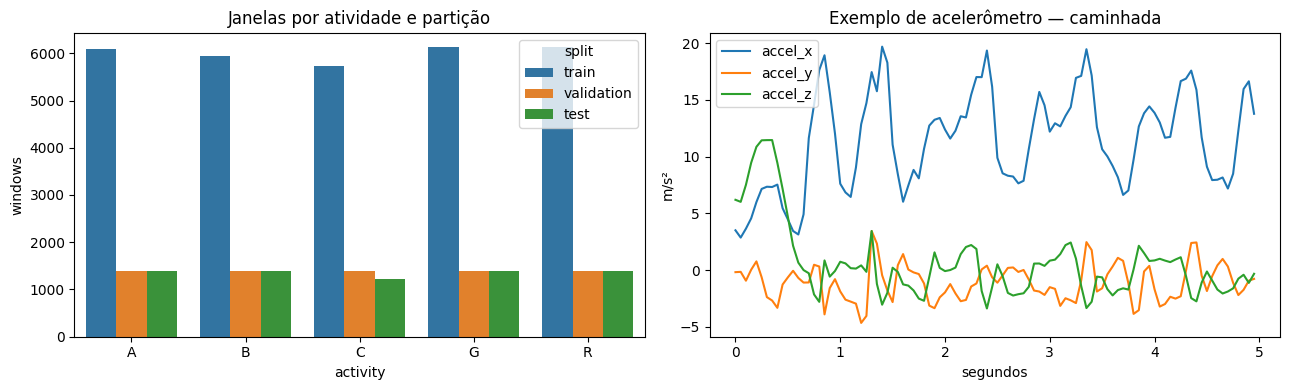

In [9]:
channel_mean = X_train.mean(axis=(0, 1), dtype=np.float64).astype(np.float32)
channel_std = X_train.std(axis=(0, 1), dtype=np.float64).astype(np.float32)
assert np.all(channel_std > 0)
normalization_table = pd.DataFrame({
    'channel': CHANNELS, 'train_mean': channel_mean, 'train_std': channel_std,
})
display(normalization_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = []
for split_name, labels in [('train', y_train), ('validation', y_val), ('test', y_test)]:
    for index, code in enumerate(ACTIVITY_CODES):
        counts.append({'split': split_name, 'activity': code,
                       'windows': int((labels == index).sum())})
sns.barplot(data=pd.DataFrame(counts), x='activity', y='windows', hue='split', ax=axes[0])
axes[0].set_title('Janelas por atividade e partição')
sample_index = np.flatnonzero(y_train == 0)[0]
axes[1].plot(np.arange(WINDOW_SAMPLES) / SAMPLE_RATE_HZ, X_train[sample_index, :, :3])
axes[1].set(title='Exemplo de acelerômetro — caminhada', xlabel='segundos', ylabel='m/s²')
axes[1].legend(CHANNELS[:3])
plt.tight_layout()
plt.show()

## 6. CNN 1D compacta

A normalização fica dentro do grafo e recebe constantes calculadas apenas no treino. Assim o app fornece valores brutos nas unidades dos sensores e não precisa copiar médias/desvios manualmente.

In [10]:
normalizer = tf.keras.layers.Normalization(
    axis=-1, mean=channel_mean, variance=np.square(channel_std),
    name='train_only_normalization',
)
inputs = tf.keras.Input(shape=(WINDOW_SAMPLES, len(CHANNELS)), name='sensor_window')
x = normalizer(inputs)
x = tf.keras.layers.Conv1D(16, 5, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(24, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(ACTIVITY_CODES), activation='softmax', name='activity')(x)
model = tf.keras.Model(inputs, outputs, name='wisdm_watch_har')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'],
)
model.summary()

weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(len(ACTIVITY_CODES)), y=y_train,
)
class_weights = {index: float(value) for index, value in enumerate(weights)}
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5,
    ),
]
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=60, batch_size=128, class_weight=class_weights,
    callbacks=callbacks, verbose=1,
)

Model: "wisdm_watch_har"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 100, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ train_only_normalization        │ (None, 100, 6)         │             0 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 24)         │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 24)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,157 (8.43 KB)

 Trainable params: 2,157 (8.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6018 - loss: 0.9278 - val_accuracy: 0.7927 - val_loss: 0.5220 - learning_rate: 0.0010
Epoch 2/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8230 - loss: 0.4345 - val_accuracy: 0.8280 - val_loss: 0.4162 - learning_rate: 0.0010
Epoch 3/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8669 - loss: 0.3369 - val_accuracy: 0.8467 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 4/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8920 - loss: 0.2864 - val_accuracy: 0.8556 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 5/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9094 - loss: 0.2512 - val_accuracy: 0.8684 - val_loss: 0.3395 - learning_rate: 0.0010
Epoch 6/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9214 - loss: 0.2231 - val_accuracy: 0.8787 - val_loss: 0.3186 - learning_rate: 0.0010
Epoch 7/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9303 - loss: 0.1993 

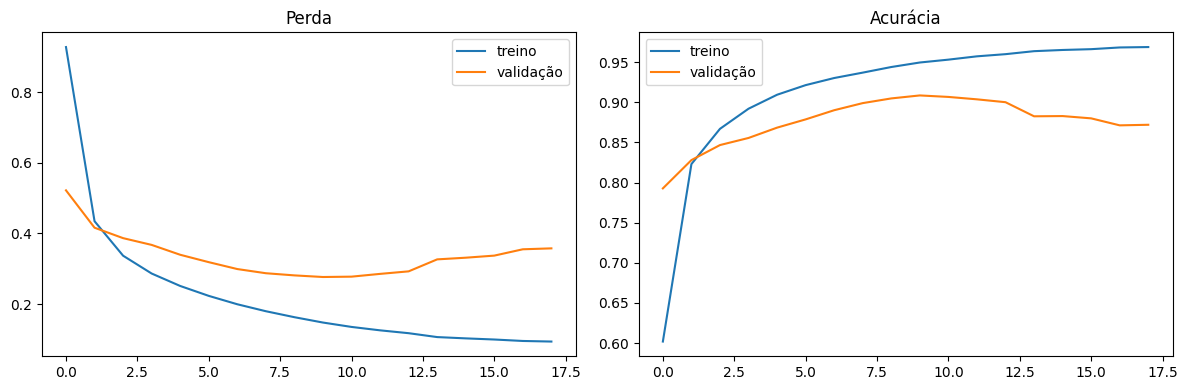

Baseline majoritário accuracy: 0.2055800293685756
Baseline majoritário macro-F1: 0.0682095006090134
Keras accuracy: 0.8387665198237886
Keras macro-F1: 0.837004900111171
                precision    recall  f1-score   support

       Walking       0.86      0.90      0.88      1401
       Jogging       0.91      1.00      0.95      1384
        Stairs       0.88      0.80      0.84      1225
Brushing Teeth       0.88      0.65      0.75      1400
      Clapping       0.70      0.85      0.77      1400

      accuracy                           0.84      6810
     macro avg       0.85      0.84      0.84      6810
  weighted avg       0.85      0.84      0.84      6810



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='treino')
axes[0].plot(history.history['val_loss'], label='validação')
axes[0].set_title('Perda'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='treino')
axes[1].plot(history.history['val_accuracy'], label='validação')
axes[1].set_title('Acurácia'); axes[1].legend()
plt.tight_layout(); plt.show()

# O teste é consultado pela primeira vez somente após o treinamento estar encerrado.
majority_class = int(np.bincount(y_train).argmax())
baseline_predictions = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_macro_f1 = f1_score(y_test, baseline_predictions, average='macro')
print('Baseline majoritário accuracy:', baseline_accuracy)
print('Baseline majoritário macro-F1:', baseline_macro_f1)
keras_probabilities = model.predict(X_test, batch_size=256, verbose=0)
keras_predictions = keras_probabilities.argmax(axis=1)
keras_accuracy = accuracy_score(y_test, keras_predictions)
keras_macro_f1 = f1_score(y_test, keras_predictions, average='macro')
print('Keras accuracy:', keras_accuracy)
print('Keras macro-F1:', keras_macro_f1)
print(classification_report(
    y_test, keras_predictions, labels=range(len(ACTIVITY_CODES)),
    target_names=[ACTIVITY_NAMES[c] for c in ACTIVITY_CODES], zero_division=0,
))

## 7. Conversão totalmente `int8`

O conjunto representativo contém apenas janelas do treino. Entrada e saída do arquivo final são `int8`.

In [12]:
representative_rng = np.random.default_rng(SEED)
representative_indices = representative_rng.choice(
    len(X_train), size=min(1000, len(X_train)), replace=False,
)

def representative_dataset():
    for index in representative_indices:
        yield [X_train[index:index + 1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()
print('Tamanho do TFLite int8:', len(tflite_model), 'bytes')

interpreter = tf.lite.Interpreter(model_content=tflite_model, num_threads=2)
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]
print('Entrada:', input_info['shape'], input_info['dtype'], input_info['quantization'])
print('Saída:', output_info['shape'], output_info['dtype'], output_info['quantization'])
assert input_info['shape'].tolist() == [1, WINDOW_SAMPLES, len(CHANNELS)]
assert output_info['shape'].tolist() == [1, len(ACTIVITY_CODES)]
assert input_info['dtype'] == np.int8 and output_info['dtype'] == np.int8

Saved artifact at '/tmp/tmpb__7rgnh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='sensor_window')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135026356924304: TensorSpec(shape=(1, 1, 6), dtype=tf.float32, name=None)
  135026356924112: TensorSpec(shape=(1, 1, 6), dtype=tf.float32, name=None)
  135026357457872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356815632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356816016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356814096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356817552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356822352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356815824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135026356822544: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Tamanho do TFLite int8: 10960 bytes
Entrada: [  1 100   6] <class 'numpy.int8'> (0.5244014859199524, 20)
Saída: [1 5] <class 'numpy.int8'> (0.00390625, -128)


TFLite accuracy: 0.8403817914831131
TFLite macro-F1: 0.8394041946115494
Queda de macro-F1: -0.002399294500378346
                precision    recall  f1-score   support

       Walking       0.87      0.90      0.88      1401
       Jogging       0.91      1.00      0.95      1384
        Stairs       0.90      0.81      0.85      1225
Brushing Teeth       0.87      0.66      0.75      1400
      Clapping       0.69      0.84      0.76      1400

      accuracy                           0.84      6810
     macro avg       0.85      0.84      0.84      6810
  weighted avg       0.85      0.84      0.84      6810



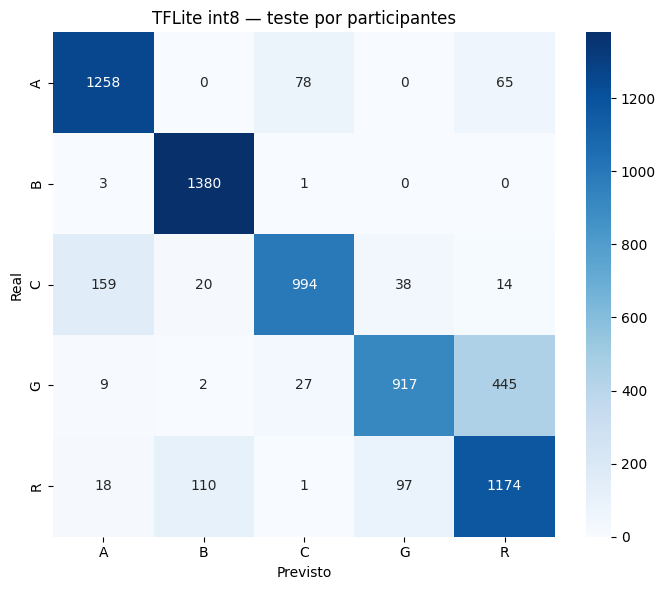

In [13]:
def evaluate_int8(interpreter, X):
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero = input_detail['quantization']
    output_scale, output_zero = output_detail['quantization']
    assert input_scale > 0 and output_scale > 0
    probabilities = []
    for window in X:
        quantized = np.clip(
            np.rint(window / input_scale + input_zero), -128, 127,
        ).astype(np.int8)[None, ...]
        interpreter.set_tensor(input_detail['index'], quantized)
        interpreter.invoke()
        raw_output = interpreter.get_tensor(output_detail['index'])[0].astype(np.int32)
        output = (raw_output - int(output_zero)) * float(output_scale)
        output = np.maximum(output, 0)
        if output.sum() > 0:
            output /= output.sum()
        probabilities.append(output)
    return np.asarray(probabilities, dtype=np.float32)

tflite_probabilities = evaluate_int8(interpreter, X_test)
tflite_predictions = tflite_probabilities.argmax(axis=1)
tflite_accuracy = accuracy_score(y_test, tflite_predictions)
tflite_macro_f1 = f1_score(y_test, tflite_predictions, average='macro')
tflite_confusion = confusion_matrix(
    y_test, tflite_predictions, labels=range(len(ACTIVITY_CODES)),
)
print('TFLite accuracy:', tflite_accuracy)
print('TFLite macro-F1:', tflite_macro_f1)
print('Queda de macro-F1:', keras_macro_f1 - tflite_macro_f1)
print(classification_report(
    y_test, tflite_predictions, labels=range(len(ACTIVITY_CODES)),
    target_names=[ACTIVITY_NAMES[c] for c in ACTIVITY_CODES], zero_division=0,
))

plt.figure(figsize=(7, 6))
sns.heatmap(
    tflite_confusion, annot=True, fmt='d', cmap='Blues',
    xticklabels=ACTIVITY_CODES, yticklabels=ACTIVITY_CODES,
)
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('TFLite int8 — teste por participantes')
plt.tight_layout(); plt.show()

assert keras_macro_f1 - tflite_macro_f1 <= 0.05, (
    'A quantização perdeu mais de 0,05 de macro-F1; revisar antes de exportar'
)

## 8. Gates finais e pacote de exportação

Os `asserts` abaixo impedem a exportação quando contrato, classes, participantes ou paridade da quantização estiverem incorretos. Macro-F1 abaixo de 0,80 gera um aviso. Caso ajuste de parametros de errado.

In [14]:
# Gates estruturais finais.
assert train_set.isdisjoint(val_set | test_set) and val_set.isdisjoint(test_set)
assert set(owner_train).issubset(train_set)
assert set(owner_val).issubset(val_set)
assert set(owner_test).issubset(test_set)
assert set(np.unique(y_train)) == set(range(5))
assert set(np.unique(y_val)) == set(range(5))
assert set(np.unique(y_test)) == set(range(5))
assert np.isfinite(channel_mean).all() and np.isfinite(channel_std).all()
assert set(representative_indices).issubset(set(range(len(X_train))))

if tflite_macro_f1 < 0.80:
    print('ATENÇÃO: macro-F1 abaixo do objetivo de 0,80. Não integrar sem discutir.')
else:
    print('Modelo atingiu o objetivo recomendado de macro-F1 >= 0,80.')

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True)
model_path = EXPORT_DIR / 'wisdm_har_int8.tflite'
model_path.write_bytes(tflite_model)
(EXPORT_DIR / 'labels.txt').write_text(
    '\n'.join(f'{code},{ACTIVITY_NAMES[code]}' for code in ACTIVITY_CODES) + '\n',
    encoding='utf-8',
)

participant_split = {
    'seed': SEED, 'train': train_subjects,
    'validation': val_subjects, 'test': test_subjects,
}
(EXPORT_DIR / 'participant_split.json').write_text(
    json.dumps(participant_split, indent=2), encoding='utf-8',
)

input_scale, input_zero = input_info['quantization']
output_scale, output_zero = output_info['quantization']
contract = {
    'model_file': model_path.name,
    'input_shape': [1, WINDOW_SAMPLES, len(CHANNELS)],
    'input_dtype': 'int8',
    'input_quantization': {'scale': float(input_scale), 'zero_point': int(input_zero)},
    'channels': CHANNELS, 'sample_rate_hz': SAMPLE_RATE_HZ,
    'window_seconds': WINDOW_SECONDS, 'hop_seconds': HOP_SECONDS,
    'max_interpolation_gap_ms': int(MAX_GAP_S * 1000),
    'output_shape': [1, len(ACTIVITY_CODES)], 'output_dtype': 'int8',
    'output_quantization': {'scale': float(output_scale), 'zero_point': int(output_zero)},
    'labels': [{'index': i, 'code': c, 'name': ACTIVITY_NAMES[c]}
               for i, c in enumerate(ACTIVITY_CODES)],
    'normalization_embedded_in_model': True,
}
(EXPORT_DIR / 'model_contract.json').write_text(
    json.dumps(contract, indent=2), encoding='utf-8',
)

metrics = {
    'majority_baseline': {'class_index': majority_class,
                          'accuracy': float(baseline_accuracy),
                          'macro_f1': float(baseline_macro_f1)},
    'keras': {'accuracy': float(keras_accuracy), 'macro_f1': float(keras_macro_f1)},
    'tflite_int8': {'accuracy': float(tflite_accuracy), 'macro_f1': float(tflite_macro_f1),
                    'confusion_matrix': tflite_confusion.tolist()},
    'window_counts': {'train': len(X_train), 'validation': len(X_val), 'test': len(X_test)},
    'model_bytes': len(tflite_model),
    'sha256': hashlib.sha256(tflite_model).hexdigest(),
    'tensorflow_version': tf.__version__,
}
(EXPORT_DIR / 'metrics.json').write_text(
    json.dumps(metrics, indent=2), encoding='utf-8',
)

model_card = f'''# Modelo WISDM Watch HAR

- Classes: {', '.join(ACTIVITY_CODES)}
- Participantes: 35 treino, 8 validação, 8 teste (sem sobreposição)
- Entrada: int8[1,100,6], 20 Hz, 5 segundos
- TFLite accuracy: {tflite_accuracy:.4f}
- TFLite macro-F1: {tflite_macro_f1:.4f}
- Tamanho: {len(tflite_model)} bytes
- SHA-256: {metrics['sha256']}

Limitação: treinado em LG G Watch do WISDM. O Galaxy Watch 6 é outro domínio.
'''
(EXPORT_DIR / 'MODEL_CARD.md').write_text(model_card, encoding='utf-8')

bundle_path = shutil.make_archive(str(WORK_DIR / 'watch_har_export'), 'zip', EXPORT_DIR)
print('Pacote pronto:', bundle_path)
print(json.dumps(metrics, indent=2))

Modelo atingiu o objetivo recomendado de macro-F1 >= 0,80.
Pacote pronto: /content/watch_har/watch_har_export.zip
{
  "majority_baseline": {
    "class_index": 4,
    "accuracy": 0.2055800293685756,
    "macro_f1": 0.0682095006090134
  },
  "keras": {
    "accuracy": 0.8387665198237886,
    "macro_f1": 0.837004900111171
  },
  "tflite_int8": {
    "accuracy": 0.8403817914831131,
    "macro_f1": 0.8394041946115494,
    "confusion_matrix": [
      [
        1258,
        0,
        78,
        0,
        65
      ],
      [
        3,
        1380,
        1,
        0,
        0
      ],
      [
        159,
        20,
        994,
        38,
        14
      ],
      [
        9,
        2,
        27,
        917,
        445
      ],
      [
        18,
        110,
        1,
        97,
        1174
      ]
    ]
  },
  "window_counts": {
    "train": 30032,
    "validation": 7000,
    "test": 6810
  },
  "model_bytes": 10960,
  "sha256": "7f847e74e804cf5314d57de11f55373e6c63f792

In [15]:
# Execute esta célula somente depois de revisar as métricas acima.
from google.colab import files
files.download(str(WORK_DIR / 'watch_har_export.zip'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>